# normal pipeline (no normalization)

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 24

In [3]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
# Import ROIs
cube.import_rois("./rois/057_5_combined.json")
cube.list_rois()

📂 Imported 6 ROIs from ./rois/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'validation_dark': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'validation_bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'validation_sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [5]:
# Apply smoothing BEFORE wavelength filter (force recompute to avoid cache issues)
cube.apply_spectral_smoothing(
    method="gaussian",
    gaussian_sigma=5.0,
)

💾 Found cached smoothing (gaussian, corrected data) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian, corrected data) from 1 files...
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)


array([[[  1.4053802 ,   1.2650696 ,   1.1382263 , ...,   1.1283655 ,
           0.97737503,   0.83948207],
        [  4.6651793 ,   4.2503104 ,   3.8811233 , ...,   1.1326705 ,
           0.9723464 ,   0.8175835 ],
        [  1.3719033 ,   1.2897086 ,   1.2119116 , ...,   1.8223882 ,
           1.5475298 ,   1.2971877 ],
        ...,
        [  1.3580438 ,   1.3156981 ,   1.2867721 , ...,   0.56639993,
           0.4903108 ,   0.43773448],
        [  3.5521085 ,   3.1614618 ,   2.791659  , ...,   1.3441232 ,
           1.1704057 ,   0.9949217 ],
        [  1.6943413 ,   1.6141984 ,   1.5584607 , ...,   2.2617679 ,
           2.1754954 ,   2.0517063 ]],

       [[  2.318576  ,   2.3062904 ,   2.2812638 , ...,   1.101198  ,
           0.9108031 ,   0.7313268 ],
        [  2.301428  ,   2.3859735 ,   2.4506774 , ...,   1.2345957 ,
           1.1081169 ,   0.99427783],
        [  2.7406316 ,   3.0454702 ,   3.413178  , ...,   1.9089841 ,
           1.5757452 ,   1.2690792 ],
        ...,


In [6]:
# Define ROI collections
training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
]

validation_rois = [
    "validation_dark",
    "validation_sediment",
    "validation_bombs",
]

print(f"Training ROIs: {training_rois}")
print(f"Validation ROIs: {validation_rois}")

Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']
Validation ROIs: ['validation_dark', 'validation_sediment', 'validation_bombs']


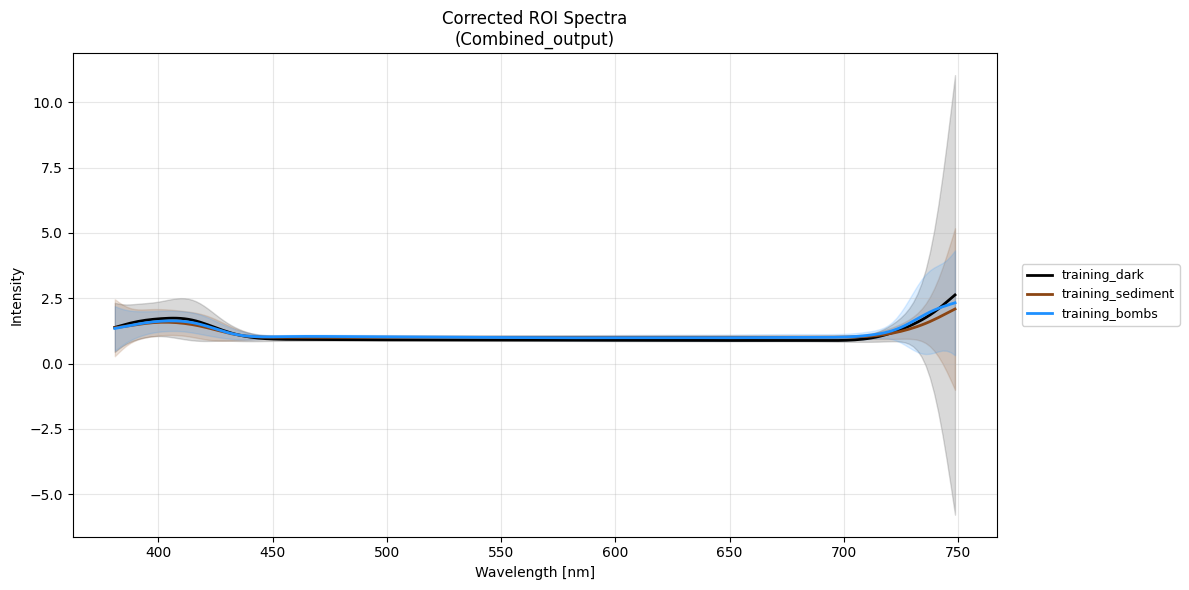

In [7]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None


💡 Interactive mode: Click on the plot to display coordinates


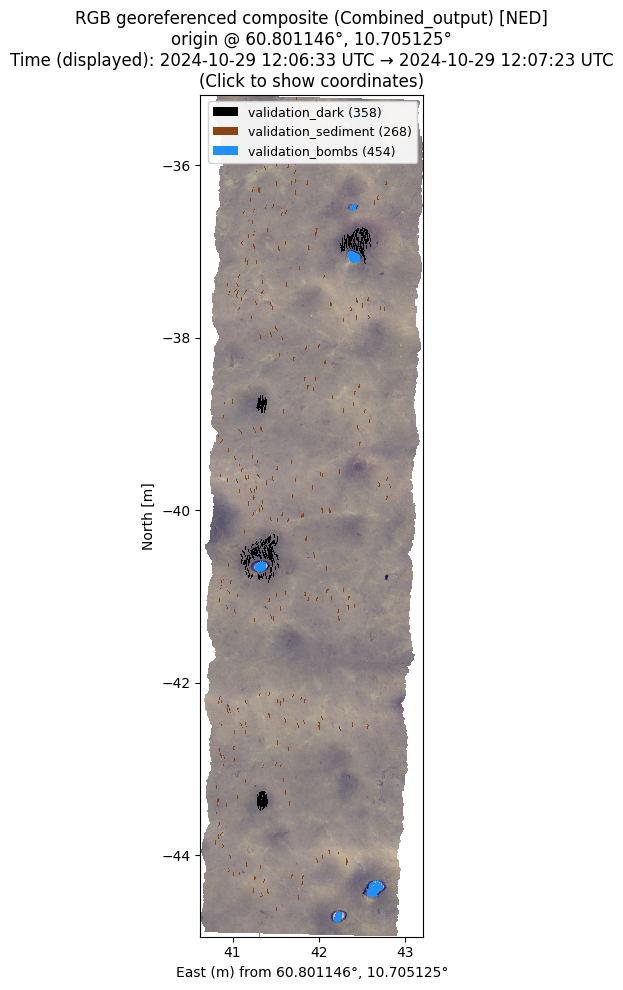

In [8]:
# Plot validation ROIs with SOLID OVERLAY
%matplotlib inline

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(30, 10),
    roi_collection=validation_rois,
    roi_solid_pixel_size=5,

    roi_overlay_mode="solid",  # NEW: Use solid pixel overlay instead of markers
)


In [9]:
# Crop wavelengths to 490-700 nm (UPDATED)
cube.apply_wavelength_filter(wavelength_range=(490, 700))

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB


array([[[1.0242817 , 1.0233774 , 1.0235972 , ..., 1.0452163 ,
         1.0459423 , 1.047293  ],
        [1.0548365 , 1.0539597 , 1.0523418 , ..., 1.0706059 ,
         1.0636694 , 1.0545129 ],
        [1.0433822 , 1.0478745 , 1.0514694 , ..., 1.0309559 ,
         1.0289329 , 1.0286332 ],
        ...,
        [1.0650878 , 1.0582087 , 1.0508734 , ..., 1.0319183 ,
         1.0231724 , 1.0166652 ],
        [1.0264505 , 1.0296129 , 1.03321   , ..., 1.0880054 ,
         1.0686986 , 1.0491787 ],
        [1.0137969 , 1.0122609 , 1.0117648 , ..., 1.0593293 ,
         1.0531667 , 1.0422413 ]],

       [[1.0191454 , 1.0156488 , 1.0118141 , ..., 1.091157  ,
         1.0910306 , 1.0903581 ],
        [1.0168545 , 1.0150243 , 1.0127909 , ..., 1.0194405 ,
         1.0147187 , 1.0108873 ],
        [1.059358  , 1.0585549 , 1.057203  , ..., 1.0557945 ,
         1.0621332 , 1.0710251 ],
        ...,
        [1.0225906 , 1.0255002 , 1.0263999 , ..., 1.1815886 ,
         1.2010847 , 1.2249782 ],
        [1.0

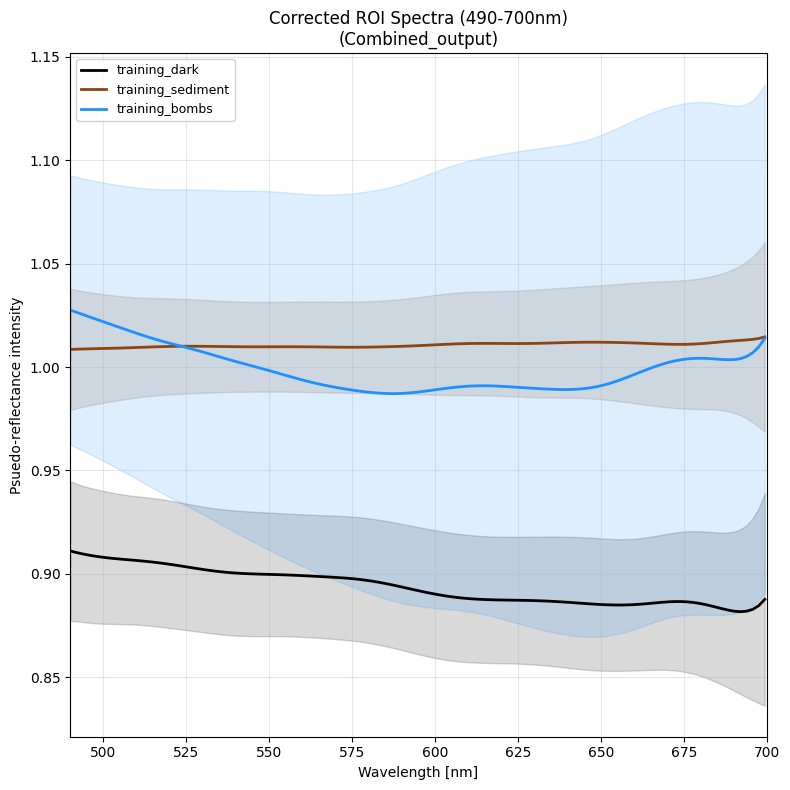

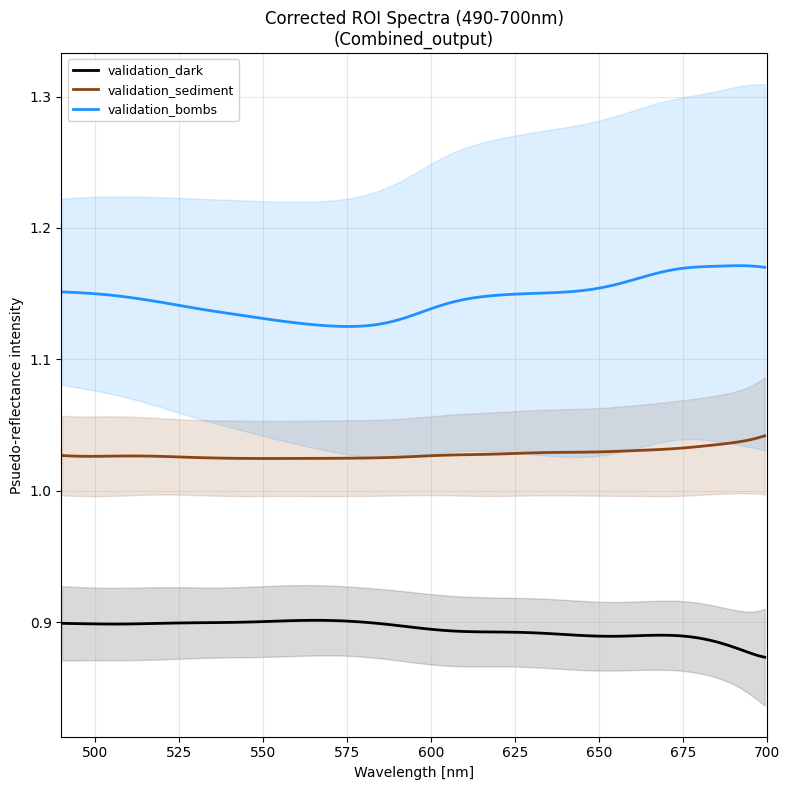

In [10]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="upper left",
    use_inline_labels=False,
    show_std=True,
    figsize=(8, 8),
    ylabel="Psuedo-reflectance intensity",
)

# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=validation_rois,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="upper left",
    use_inline_labels=False,
    show_std=True,
    figsize=(8, 8),
    ylabel="Psuedo-reflectance intensity",
)

In [11]:
# Train SVM with spatial cross-validation
cv_results = cube.train_svm_with_cv(
    training_rois=training_rois,
    segment_start=config.UHI_TRACK_RANGE[0],
    segment_end=config.UHI_TRACK_RANGE[1] - 1,
    cv_folds=5,
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    add_brightness_feature=False,
    quiet=False,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used:")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

🤖 SVM TRAINING WITH CROSS-VALIDATION
💡 MODE: Standard spectral classification

�📦 Datacube shape: (2462, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1565
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']

🔍 Filtering ROI pixels...
   training_dark: 364 pixels (rejected 0 inside segment)
   training_sediment: 397 pixels (rejected 1 inside segment)
   training_bombs: 201 pixels (rejected 0 inside segment)

✅ Training data: 962 pixels, 119 features
   Features: 119 wavelengths
   Kept (outside segment): 962
   Rejected (inside segment): 1

🔬 Creating spatial groups for CV...
   Settings: closing_radius=3, min_group_size=20
   Sediment grid: 100(slit) × 200(track) px, min=10
   training_dark: 364 pixels → 6 groups via connected_components
      dark#A: 119 pixels
      dark#B: 50 pixels
      dark#C: 37 pixels
      dark#D: 29 pixels
      dark#E: 51 pixels
      dark#F: 78 pixels
      Merged small tile (11, 2) (9 px) → neighbor tile
      Merg

In [12]:
# Compute additional CV metrics
from sklearn.metrics import cohen_kappa_score

print(f"\n" + "=" * 60)
print(f"📊 ADDITIONAL CV METRICS")
print(f"=" * 60)

# Macro F1 (average F1 across all classes)
macro_f1_mean = cv_results["cv_mean_metrics"]["f1_mean"]
macro_f1_std = cv_results["cv_mean_metrics"]["f1_std"]

print(f"Macro F1:  {macro_f1_mean:.3f} ± {macro_f1_std:.3f}")

# Kappa is computed per-fold during CV, let's extract if available
# Note: If not available in cv_results, we can compute from validation later
if "kappa_mean" in cv_results["cv_mean_metrics"]:
    kappa_mean = cv_results["cv_mean_metrics"]["kappa_mean"]
    kappa_std = cv_results["cv_mean_metrics"]["kappa_std"]
    print(f"Cohen's Kappa (κ): {kappa_mean:.3f} ± {kappa_std:.3f}")

    # Interpretation
    if kappa_mean > 0.8:
        interpretation = "Strong agreement"
    elif kappa_mean > 0.6:
        interpretation = "Substantial agreement"
    elif kappa_mean > 0.4:
        interpretation = "Moderate agreement"
    elif kappa_mean > 0.2:
        interpretation = "Fair agreement"
    else:
        interpretation = "Slight agreement"
    print(f"   Interpretation: {interpretation}")
else:
    print("⚠️  Kappa not computed during CV (will compute from validation)")

print("=" * 60)


📊 ADDITIONAL CV METRICS
Macro F1:  0.593 ± 0.012
⚠️  Kappa not computed during CV (will compute from validation)


🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


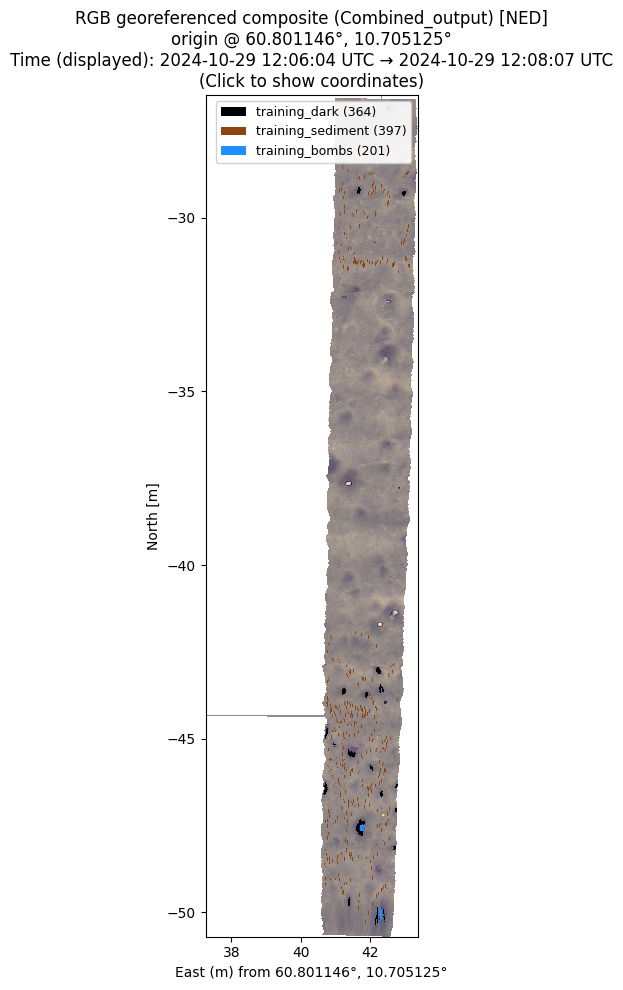

In [13]:
# Visualize filtered training ROIs
cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results["filtered_training_rois"],
    roi_marker_edgewidth=0,
    roi_solid_pixel_size=11,
    roi_overlay_mode="solid",
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


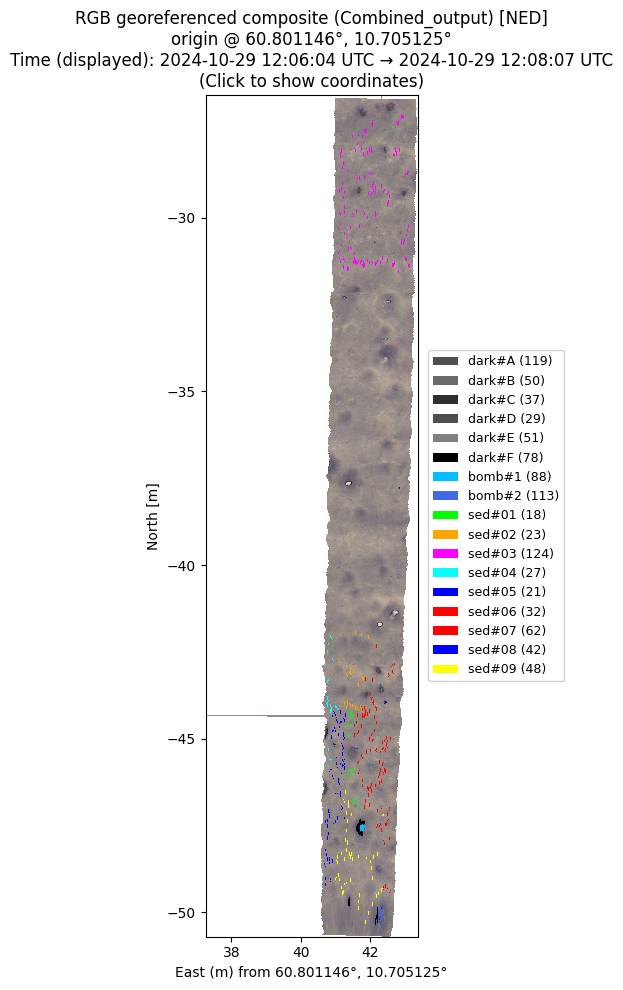


📊 Spatial Groups Created:
   bomb#1: 88 pixels
   bomb#2: 113 pixels
   dark#A: 119 pixels
   dark#B: 50 pixels
   dark#C: 37 pixels
   dark#D: 29 pixels
   dark#E: 51 pixels
   dark#F: 78 pixels
   sed#01: 18 pixels
   sed#02: 23 pixels
   sed#03: 124 pixels
   sed#04: 27 pixels
   sed#05: 21 pixels
   sed#06: 32 pixels
   sed#07: 62 pixels
   sed#08: 42 pixels
   sed#09: 48 pixels


In [14]:
# Plot spatial groups created during training
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results["spatial_groups_roi_collection"],
        roi_marker_size=3,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
        roi_solid_pixel_size=11,
        roi_overlay_mode="solid",
    )

    # Print group info
    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")
else:
    print(
        "⚠️ No spatial groups found in cv_results. Training may not have used spatial clustering."
    )


🔧 Interpolating 3 wavelength(s):
   • Index 64: 602.39 nm
   • Index 107: 679.43 nm
   ⚠️  Index 138 out of range (0-118)



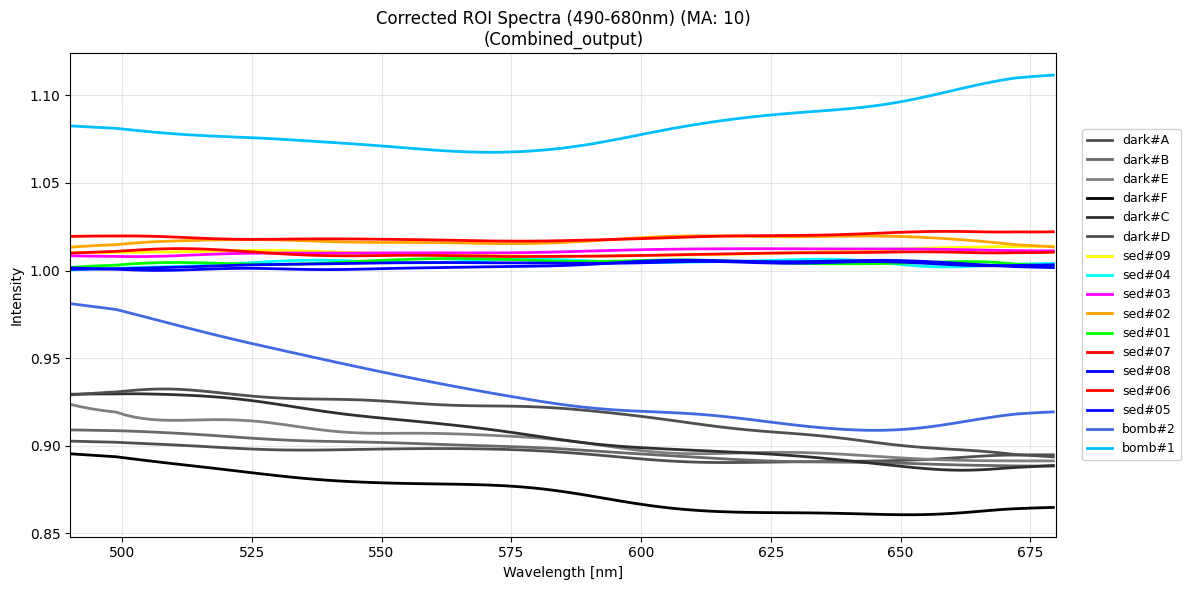

In [15]:
# Plot spectra for all spatial groups
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    # Temporarily add spatial groups to ROI collection
    original_rois = cube.roi_collection.copy()
    cube.roi_collection.update(cv_results["spatial_groups_roi_collection"])

    # Plot spectra
    cube.plot_spectrum(
        roi_names=list(cv_results["spatial_groups_roi_collection"].keys()),
        use_corrected=True,
        wavelength_range=(490, 680),
        wavelength_smoothing=10,
        interpolate_wavelengths=[64, 107, 138],
        normalize_method=None,
        legend_loc="outside",
        use_inline_labels=False,
        show_std=False,
    )

    # Restore original ROI collection
    cube.roi_collection = original_rois
else:
    print("⚠️ No spatial groups found in cv_results.")

In [16]:
# Classify segment - outputs classified_bombs, classified_dark, classified_sediment
print("🎯 STEP 1: CLASSIFICATION")
print("=" * 60)

classification_results = cube.classify_segment(
    segment_start=config.UHI_TRACK_RANGE[0],
    segment_end=config.UHI_TRACK_RANGE[1] - 1,
    use_corrected=True,
    quiet=False,
    confidence_threshold=0,  # ✅ NEW: Reject low-confidence pixels
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results["class_names"]:
    count = np.sum(classification_results["classification_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

🎯 STEP 1: CLASSIFICATION
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.00
   (Pixels with max_prob < 0.00 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📊 Using wavelength subset: 119 wavelengths

📦 Datacube shape: (2462, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1565

🔪 Extracting segment...
   Segment shape: (990, 968, 119)

🤖 Classifying 958320 pixels...

📊 Using wavelength subset: 119 wavelengths

📦 Datacube shape: (2462, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1565

🔪 Extracting segment...
   Segment shape: (990, 968, 119)

🤖 Classifying 958320 pixels...


   Classifying: 100%|█████████████████████████████████| 958320/958320 [01:42<00:00, 9326.55pixels/s]




🎲 Confidence Thresholding:
   Threshold: 0.00
   Unknown pixels: 0 (0.0%)
   Confidence range: [0.333, 1.000]
   ✅ Classification complete in 103.14 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 2610 pixels (0.3%)
   classified_dark: 88456 pixels (9.2%)
   classified_sediment: 867254 pixels (90.5%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes: ['classified_bombs', 'classified_dark', 'classified_sediment']

📊 Pixel counts:
   classified_bombs: 2610 pixels
   classified_dark: 88456 pixels
   classified_sediment: 867254 pixels

✅ Classification complete!
   Classes: ['classified_bombs', 'classified_dark', 'classified_sediment']

📊 Pixel counts:
   classified_bombs: 2610 pixels
   classified_dark: 88456 pixels
   classified_sediment: 867254 pixels


📊 Plotting classification map (3 classes)...
📊 Plotting classification map...
   Classes: ['bombs', 'dark', 'sediment']
   🎨 Inherited colors from validation/training ROIs:
      bombs: #1E90FF
      dark: #000000
      sediment: #8b4513
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


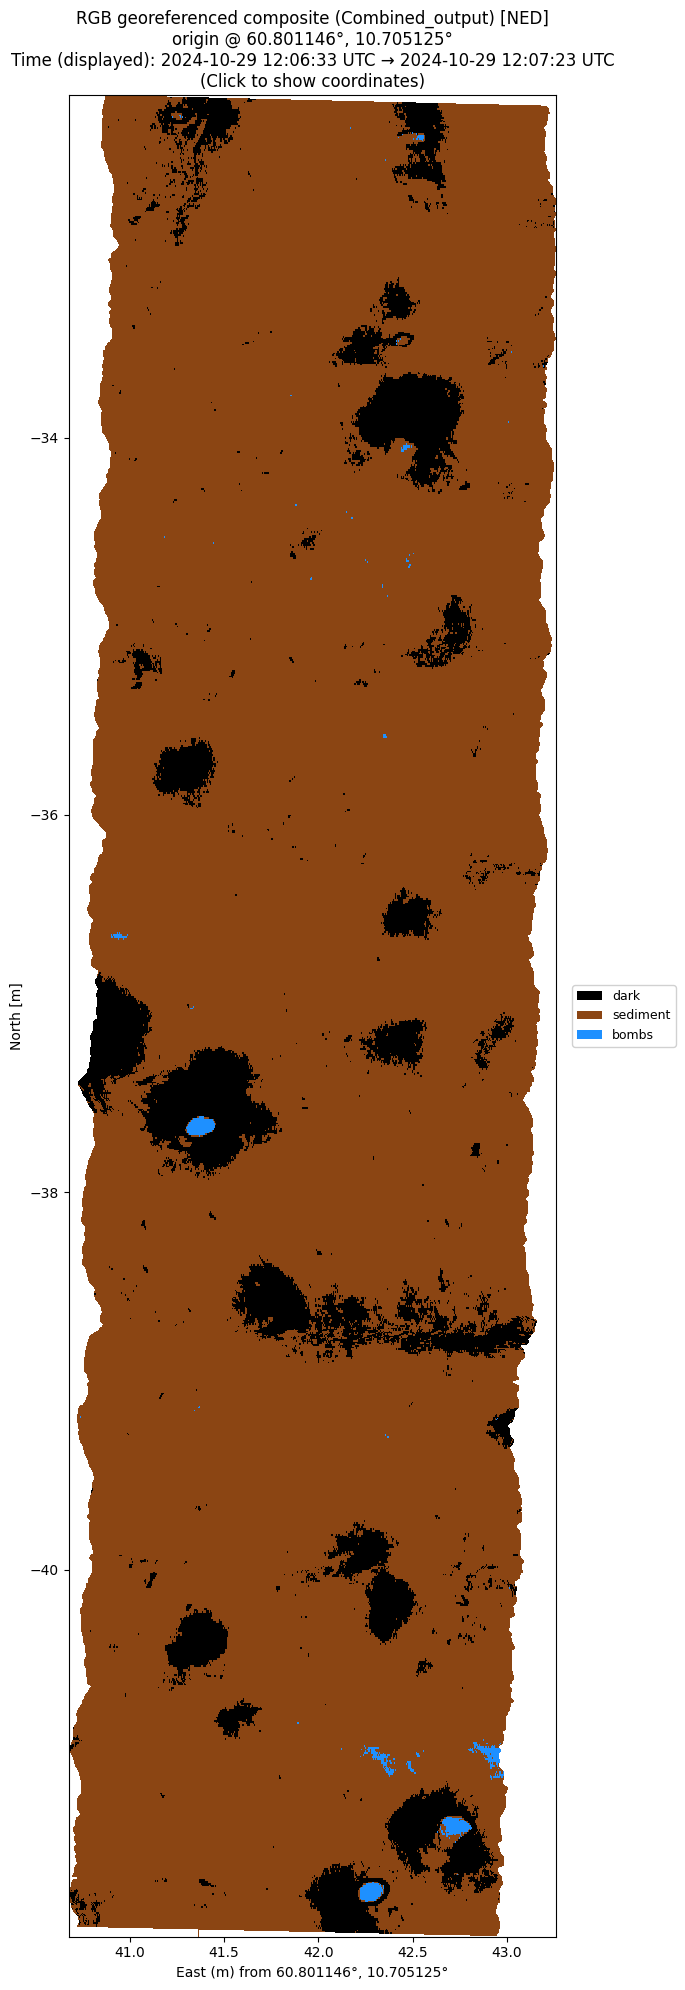

In [17]:
# Plot classification (3 classes) - using helper function
print("📊 Plotting classification map (3 classes)...")

# Optional: Define class name mapping for cleaner display (or use original names)
class_name_mapping = {
    "classified_bombs": "bombs",
    "classified_dark": "dark",
    "classified_sediment": "sediment",
}

# Use the helper function
plot_classification_map(
    cube=cube,
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    class_name_mapping=class_name_mapping,  # Optional: rename classes
    show_pixel_counts=False,  # Show pixel counts in legend
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_solid_pixel_size=1,
)

In [18]:
# 🎨 TEST: Check color inheritance (before reloading module)
print("Current ROI color map (colors assigned from validation ROIs):")
if hasattr(cube, "roi_color_map"):
    for roi_name, color in sorted(cube.roi_color_map.items()):
        if "validation" in roi_name or "training" in roi_name:
            print(f"  {roi_name}: {color}")
else:
    print("  No color map found")

Current ROI color map (colors assigned from validation ROIs):
  training_bombs: #1E90FF
  training_dark: #000000
  training_sediment: #8b4513
  validation_bombs: #1E90FF
  validation_dark: #000000
  validation_sediment: #8b4513


In [19]:
# 🔄 Reload the georef module to get the updated plot_classification_map function
import importlib
from utils.uhi import georef

importlib.reload(georef)
from utils.uhi.georef import plot_classification_map

print("✅ Module reloaded with color inheritance fix!")

✅ Module reloaded with color inheritance fix!


## 🎨 COLOR REFERENCE GUIDE

**Where colors are defined:**
- File: `e:\mjosa_complete\gref4hsi\mjosa_code\utils\uhi\georef.py`
- Location: Line ~749, inside `_get_roi_color()` method
- Constants: `COLOR_BOMBS`, `COLOR_DARK`, `COLOR_SEDIMENT`

**Color palette:**
```python
COLOR_BOMBS = "#1E90FF"      # dodger blue
COLOR_DARK = "#000000"       # black  
COLOR_SEDIMENT = "#8B4513"   # saddle brown
```

**How names map to colors in this cell:**

| Original Class | Mapped Name | Color Used |
|---|---|---|
| `classified_bombs` | `bombs` | `COLOR_BOMBS` (#1E90FF - blue) |
| `classified_dark` | `dark areas` | `COLOR_DARK` (#000000 - black) |
| `classified_sediment` | `sediment` | `COLOR_SEDIMENT` (#8B4513 - brown) |

**To change colors:**
1. Edit the constants at line 752-756 in `georef.py`
2. All related ROIs will automatically update:
   - `validation_*`, `training_*`, `classified_*`, `bombs`, `dark`, `sediment`

**Examples:**
- Change all bomb colors: `COLOR_BOMBS = "#FF0000"` (red)
- Change all dark colors: `COLOR_DARK = "#2F2F2F"` (dark gray)
- Change all sediment colors: `COLOR_SEDIMENT = "#A0522D"` (sienna)

In [20]:
# Apply filtering - creates filtered_bombs and filtered_dark
print("\n🧹 STEP 2: FILTERING")
print("=" * 60)

filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,
    filter_dark=True,
    filter_sediment=False,
    min_area_px=10,
    connectivity=8,
    morph_close_radius=0,  # Disabled
    morph_open_radius=0,  # Disabled
    merge_proximity_px=0,
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   All classes after filtering: {filtering_results['all_classes']}")


🧹 STEP 2: FILTERING
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['classified_bombs', 'classified_dark']
   Connectivity: 8
   Min area: 10 pixels
   Morph close radius: 0 (disabled)
   Morph open radius: 0 (disabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering classified_bombs (bomb)...
      Found 134 connected components
      Kept: 14 components (2369 pixels)
      Removed: 120 components (241 pixels)
      ✂️  Reclassified 241 pixels as filtered_bombs
      Final: 2369 pixels (241 removed, 9.2%)

   🔍 Filtering classified_dark (dark)...
      Found 1375 connected components
      Kept: 176 components (85599 pixels)
      Removed: 1199 components (2857 pixels)
      ✂️  Reclassified 2857 pixels as filtered_dark
      Final: 85599 pixels (2857 removed, 3.2%)

✅ Post-classification filtering complete
      Kept: 176 components (85599 pixels)
      Removed: 1199 components (2857 pixels)
      ✂️  Reclassified 2857 pixels as filtered_d

📊 Plotting filtered map (5 classes: classified_* + filtered_*)...
📊 Plotting classification map...
   Classes: ['bombs (2369 px)', 'dark (85599 px)', 'sediment (867254 px)', 'filtered_bombs (241 px)', 'filtered_dark (2857 px)']
   🎨 Inherited colors from validation/training ROIs:
      bombs (2369 px): #1E90FF
      dark (85599 px): #000000
      sediment (867254 px): #8b4513
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
📊 Plotting classification map...
   Classes: ['bombs (2369 px)', 'dark (85599 px)', 'sediment (867254 px)', 'filtered_bombs (241 px)', 'filtered_dark (2857 px)']
   🎨 Inherited colors from validation/training ROIs:
      bombs (2369 px): #1E90FF
      dark (85599 px): #000000
      sediment (867254 px): #8b4513
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordi

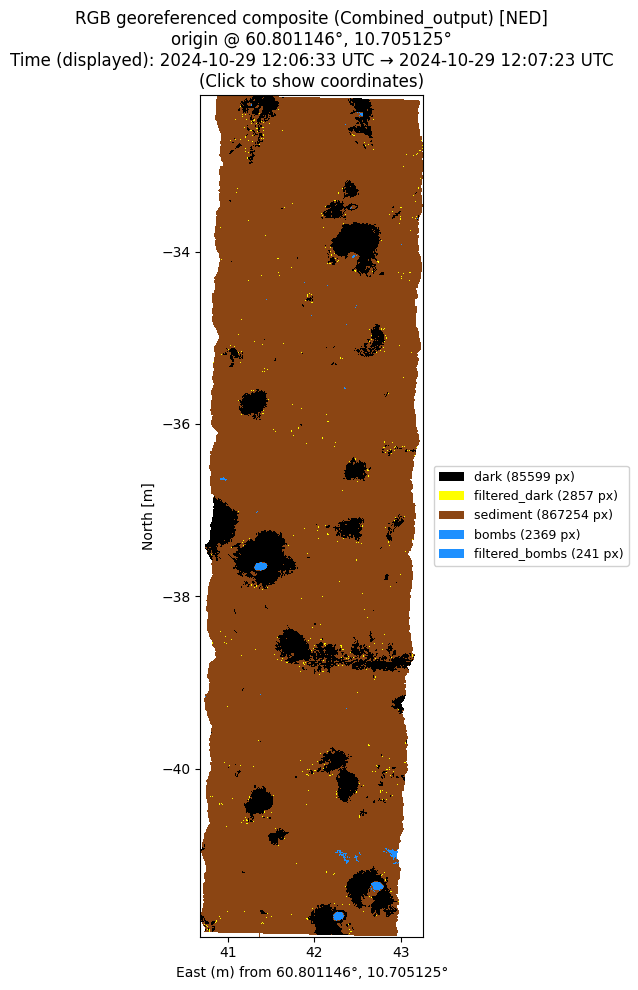

In [21]:
# Plot filtered map (5 classes!) - using helper function
print("📊 Plotting filtered map (5 classes: classified_* + filtered_*)...")

# Optional: Define class name mapping for cleaner display
class_name_mapping = {
    "classified_bombs": "bombs",
    "classified_dark": "dark",
    "classified_sediment": "sediment",
    "filtered_bombs": "filtered_bombs",
    "filtered_dark": "filtered_dark",
}

# Use the helper function
plot_classification_map(
    cube=cube,
    classification_map=filtering_results["filtered_map"],
    class_names=filtering_results["all_classes"],
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(40, 10),
    class_name_mapping=class_name_mapping,  # Optional: rename classes
    show_pixel_counts=True,  # Show pixel counts in legend
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_solid_pixel_size=1,
)

In [22]:
# Merge filtered classes into new_sediment
print("\n🔀 STEP 3: MERGE FILTERED CLASSES")
print("=" * 60)

merge_results = cube.merge_filtered_to_sediment(
    filtered_map=filtering_results["filtered_map"],
    quiet=False,
)

print(f"\n✅ Merge complete!")
print(f"   Final classes for validation: {merge_results['class_names']}")


🔀 STEP 3: MERGE FILTERED CLASSES
🔀 MERGING FILTERED CLASSES TO SEDIMENT

📊 Before merge:
   classified_bombs: 2369 pixels
   classified_dark: 85599 pixels
   classified_sediment: 867254 pixels
   filtered_bombs: 241 pixels
   filtered_dark: 2857 pixels

🔀 Merged into new_sediment:
   classified_sediment: 867254 pixels
   filtered_bombs: 241 pixels
   filtered_dark: 2857 pixels
   ─────────────────────────
   Total: 870352 pixels

📊 After merge (3 classes for validation):
   classified_bombs: 2369 pixels
   classified_dark: 85599 pixels
   new_sediment: 870352 pixels

✅ Merge complete!
   Final classes for validation: ['classified_bombs', 'classified_dark', 'new_sediment']

🔀 Merged into new_sediment:
   classified_sediment: 867254 pixels
   filtered_bombs: 241 pixels
   filtered_dark: 2857 pixels
   ─────────────────────────
   Total: 870352 pixels

📊 After merge (3 classes for validation):
   classified_bombs: 2369 pixels
   classified_dark: 85599 pixels
   new_sediment: 870352 pixel

📊 Plotting validation map (3 classes)...
📊 Plotting classification map...
   Classes: ['bombs', 'dark', 'sediment']
   🎨 Inherited colors from validation/training ROIs:
      bombs: #1E90FF
      dark: #000000
      sediment: #8b4513
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


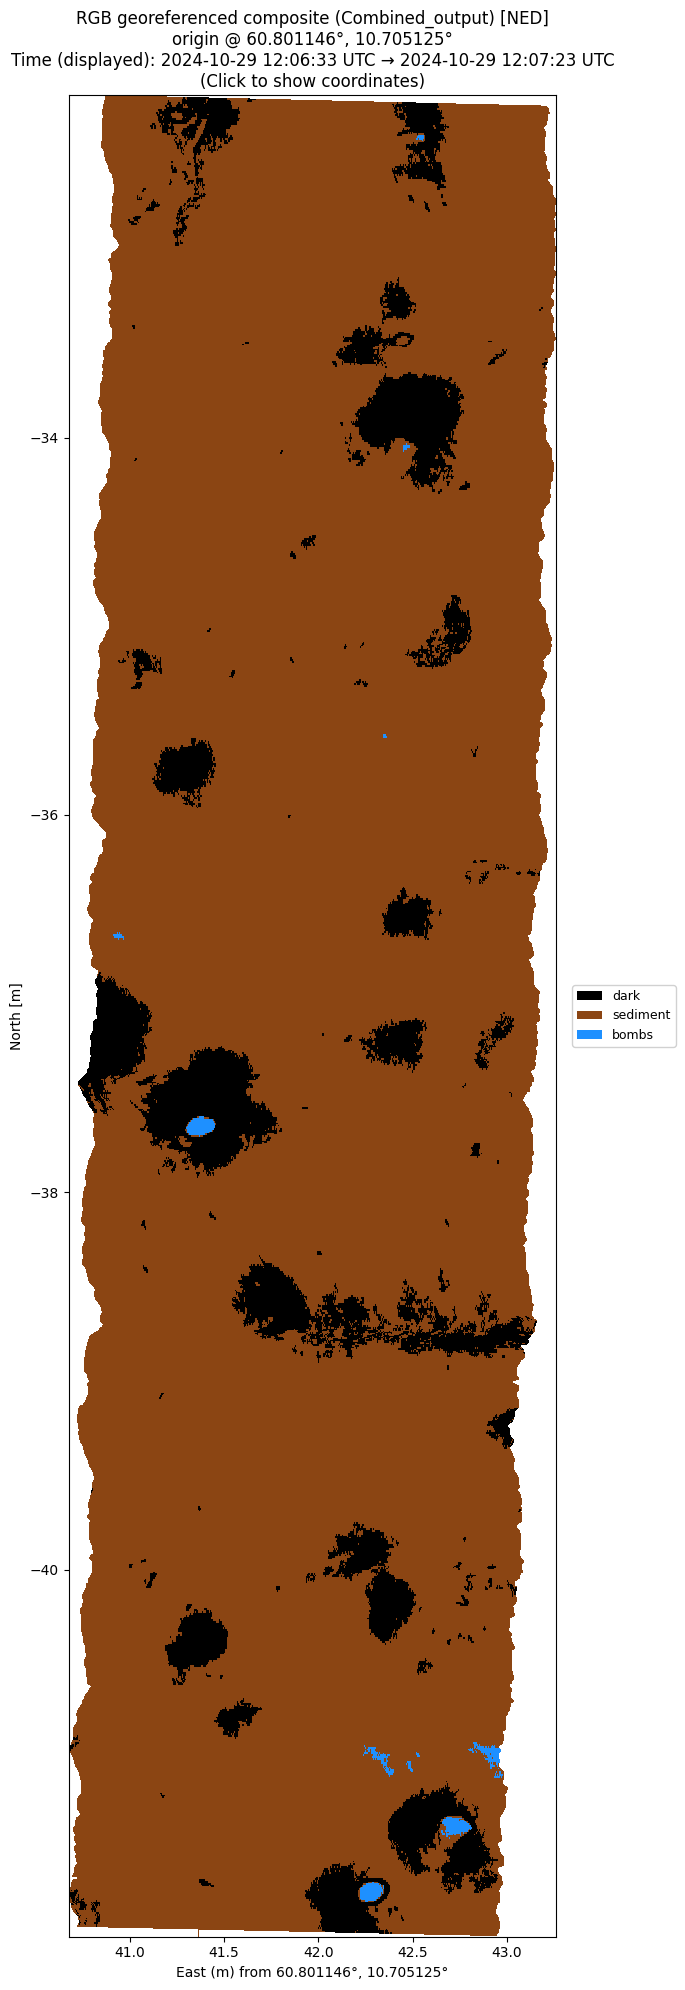

In [ ]:
# Plot validation map (3 classes) - using helper function
print("📊 Plotting validation map (3 classes)...")

# Define class name mapping for cleaner display
class_name_mapping = {
    "classified_bombs": "bombs",
    "classified_dark": "dark",
    "new_sediment": "sediment",
}

# Use the helper function with customizable parameters
plot_classification_map(
    cube=cube,
    classification_map=merge_results["validation_map"],
    class_names=merge_results["class_names"],
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    class_name_mapping=class_name_mapping,  # Rename classes for display
    show_pixel_counts=False,  # Clean legend labels without counts in name
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_solid_pixel_size=1,
)

In [24]:
# Check what classes are in validation_map
unique_classes = np.unique(merge_results["validation_map"])
print(f"Classes in validation_map: {unique_classes}")
print(f"Expected classes: {merge_results['class_names']}")

# Count pixels per class
for class_name in unique_classes:
    count = np.sum(merge_results["validation_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

Classes in validation_map: ['classified_bombs' 'classified_dark' 'new_sediment']
Expected classes: ['classified_bombs', 'classified_dark', 'new_sediment']
   classified_bombs: 2369 pixels
   classified_dark: 85599 pixels
   new_sediment: 870352 pixels


In [ ]:
# Validate using the 3-class map
print("\n📊 STEP 4: VALIDATION")
print("=" * 60)

validation_results = cube.validate_classification(
    classification_map=merge_results["validation_map"],
    segment_start=config.UHI_TRACK_RANGE[0],
    segment_end=config.UHI_TRACK_RANGE[1] - 1,
    validation_rois=validation_rois,
    validation_class_mapping={
        "validation_sediment": "new_sediment",
        "validation_dark": "classified_dark",
        "validation_bombs": "classified_bombs",
    },
    quiet=False,
)

# Print summary
if validation_results:
    print(f"\n" + "=" * 60)
    print(f"📊 VALIDATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results:")
    for class_name in merge_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results['precision_per_class'][class_name]:.3f}"
        )
        print(f"  Recall:    {validation_results['recall_per_class'][class_name]:.3f}")
        print(f"  F1 Score:  {validation_results['f1_per_class'][class_name]:.3f}")
        print(
            f"  Support:   {validation_results['support_per_class'][class_name]} pixels"
        )


📊 STEP 4: VALIDATION
📊 CLASSIFICATION VALIDATION

   Classes in classification: ['classified_bombs', 'classified_dark', 'new_sediment']
   Classes in validation: ['classified_bombs', 'classified_dark', 'new_sediment']

📈 Validation Results:
   Overall Accuracy: 0.792

   Per-Class Metrics:
   classified_bombs: P=0.992, R=0.515, F1=0.678, Support=454
   classified_dark: P=0.967, R=0.992, F1=0.979, Support=358
   new_sediment: P=0.558, R=0.993, F1=0.714, Support=268

📊 VALIDATION RESULTS
Overall Accuracy: 0.792

📋 Per-Class Results:

classified_bombs:
  Precision: 0.992
  Recall:    0.515
  F1 Score:  0.678
  Support:   454 pixels

classified_dark:
  Precision: 0.967
  Recall:    0.992
  F1 Score:  0.979
  Support:   358 pixels

new_sediment:
  Precision: 0.558
  Recall:    0.993
  F1 Score:  0.714
  Support:   268 pixels

   Classes in classification: ['classified_bombs', 'classified_dark', 'new_sediment']
   Classes in validation: ['classified_bombs', 'classified_dark', 'new_sediment'

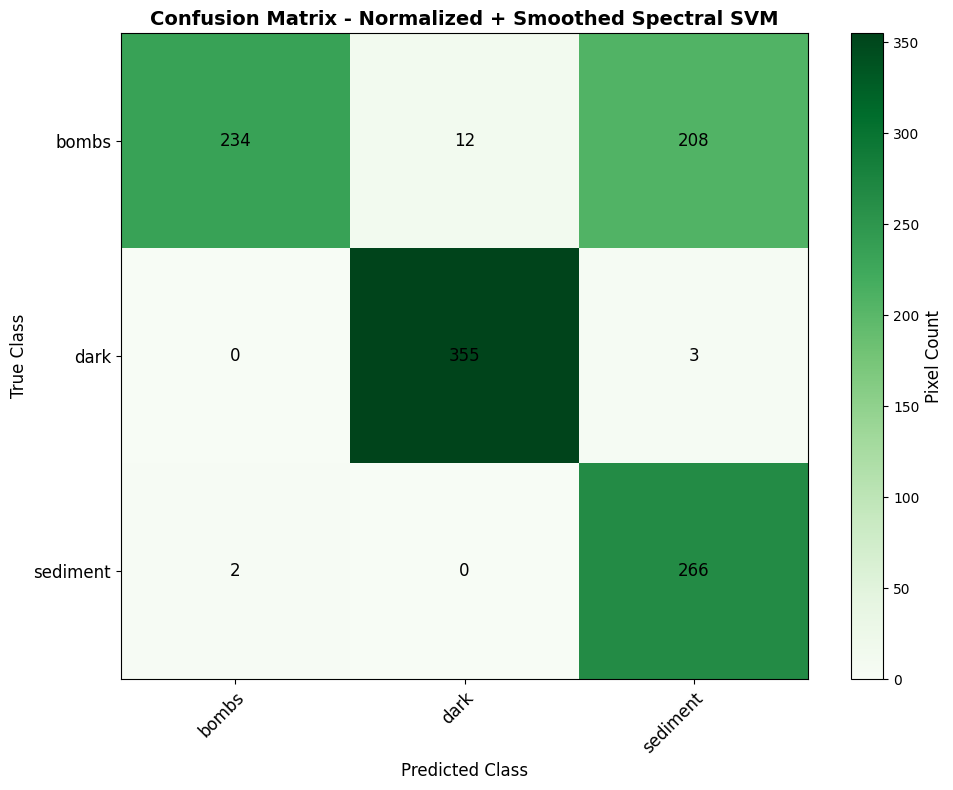


📊 Confusion Matrix (Normalized by True Class - Row %):
                                   bombs                dark            sediment
--------------------------------------------------------------------------------
bombs                              51.5%                2.6%               45.8%
dark                                0.0%               99.2%                0.8%
sediment                            0.7%                0.0%               99.3%


In [26]:
# Plot confusion matrix using helper function
if validation_results:
    # Define class name mapping for cleaner display
    class_name_mapping = {
        "classified_bombs": "bombs",
        "classified_dark": "dark",
        "new_sediment": "sediment",
    }

    # Use the helper function with customizable parameters
    fig, ax = plot_confusion_matrix(
        confusion_matrix=validation_results["confusion_matrix"],
        class_names=merge_results["class_names"],
        class_name_mapping=class_name_mapping,  # Rename classes for display
        figsize=(10, 8),  # Adjust size as needed
        cmap="Greens",  # Colormap
        title="Confusion Matrix - Normalized + Smoothed Spectral SVM",
        normalize=True,  # Print normalized percentages
        show_counts=True,  # Show pixel counts in cells
        fontsize_labels=12,  # Axis label font size
        fontsize_title=14,  # Title font size
        fontsize_cells=12,  # Cell text font size
        show_colorbar=True,  # Show colorbar
    )

In [27]:
# 📊 COMPREHENSIVE CONFUSION MATRIX ANALYSIS
# Compute all confusion matrix metrics using the utility function

from utils.uhi.georef import compute_confusion_matrix_metrics

if validation_results:
    # Define class name mapping for cleaner display
    class_name_mapping = {
        "classified_bombs": "bombs",
        "classified_dark": "dark",
        "new_sediment": "sediment",
    }

    # Compute metrics and get structured data
    cm_metrics = compute_confusion_matrix_metrics(
        confusion_matrix=validation_results["confusion_matrix"],
        class_names=merge_results["class_names"],
        validation_results=validation_results,
        class_name_mapping=class_name_mapping,
        print_analysis=True,  # Print detailed analysis
    )

    # Now you can access any metric programmatically:
    # cm_metrics['overall_accuracy']
    # cm_metrics['cohens_kappa']
    # cm_metrics['producers_accuracy']['classified_bombs']
    # cm_metrics['users_accuracy']['classified_dark']
    # cm_metrics['cm_normalized']  # Normalized confusion matrix
    # etc.

else:
    print("❌ No validation_results found. Run validation first!")

📊 CONFUSION MATRIX ANALYSIS

1️⃣ CONFUSION MATRIX - PIXEL COUNTS
--------------------------------------------------------------------------------
                |        bombs |         dark |     sediment | Row Total
--------------------------------------------------------------------------------
          bombs |          234 |           12 |          208 |          454
           dark |            0 |          355 |            3 |          358
       sediment |            2 |            0 |          266 |          268
--------------------------------------------------------------------------------
   Column Total |          236 |          367 |          477 |        1,080

2️⃣ ROW TOTALS (True pixels per class)
--------------------------------------------------------------------------------
            bombs:        454 pixels
             dark:        358 pixels
         sediment:        268 pixels
            TOTAL:      1,080 pixels

3️⃣ COLUMN TOTALS (Predicted pixels per class

## 📋 Accessing Confusion Matrix Metrics

The `cm_metrics` dictionary contains all computed metrics. You can access them programmatically for creating tables, reports, or further analysis.

In [ ]:
# # Example: Access specific metrics from cm_metrics
# if "cm_metrics" in globals() and cm_metrics:
#     print("=" * 60)
#     print("📊 EXAMPLE: Accessing Structured Metrics")
#     print("=" * 60)

#     # Overall metrics
#     print(f"\n✅ Overall Accuracy: {cm_metrics['overall_accuracy']:.1%}")
#     print(
#         f"✅ Cohen's Kappa: {cm_metrics['cohens_kappa']:.3f} ({cm_metrics['kappa_interpretation']})"
#     )

#     # Per-class metrics
#     print(f"\n📋 Per-Class Metrics:")
#     for class_name in cm_metrics["class_names"]:
#         pa = cm_metrics["producers_accuracy"][class_name]
#         ua = cm_metrics["users_accuracy"][class_name]
#         print(f"\n  {class_name}:")
#         print(f"    Producer's Accuracy (Recall): {pa:.1%}")
#         print(f"    User's Accuracy (Precision): {ua:.1%}")
#         if cm_metrics["f1_per_class"]:
#             f1 = cm_metrics["f1_per_class"][class_name]
#             print(f"    F1 Score: {f1:.3f}")

#     # Access raw data for creating tables
#     print(f"\n💡 Available metrics in cm_metrics:")
#     print(f"   - confusion_matrix: {cm_metrics['confusion_matrix'].shape}")
#     print(f"   - cm_normalized: {cm_metrics['cm_normalized'].shape}")
#     print(f"   - row_totals: {len(cm_metrics['row_totals'])} classes")
#     print(f"   - col_totals: {len(cm_metrics['col_totals'])} classes")
#     print(f"   - total_pixels: {cm_metrics['total_pixels']:,}")
#     print(
#         f"   - producers_accuracy: dict with {len(cm_metrics['producers_accuracy'])} classes"
#     )
#     print(f"   - users_accuracy: dict with {len(cm_metrics['users_accuracy'])} classes")

#     print("\n" + "=" * 60)
# else:
#     print("⚠️  Run the confusion matrix analysis cell first!")

📊 EXAMPLE: Accessing Structured Metrics

✅ Overall Accuracy: 79.2%
✅ Cohen's Kappa: 0.696 (Substantial agreement)

📋 Per-Class Metrics:

  classified_bombs:
    Producer's Accuracy (Recall): 51.5%
    User's Accuracy (Precision): 99.2%
    F1 Score: 0.678

  classified_dark:
    Producer's Accuracy (Recall): 99.2%
    User's Accuracy (Precision): 96.7%
    F1 Score: 0.979

  new_sediment:
    Producer's Accuracy (Recall): 99.3%
    User's Accuracy (Precision): 55.8%
    F1 Score: 0.714

💡 Available metrics in cm_metrics:
   - confusion_matrix: (3, 3)
   - cm_normalized: (3, 3)
   - row_totals: 3 classes
   - col_totals: 3 classes
   - total_pixels: 1,080
   - producers_accuracy: dict with 3 classes
   - users_accuracy: dict with 3 classes



In [ ]:
# # Compute additional validation metrics
# from sklearn.metrics import cohen_kappa_score
# import numpy as np

# if validation_results:
#     print(f"\n" + "=" * 60)
#     print(f"📊 ADDITIONAL VALIDATION METRICS")
#     print(f"=" * 60)

#     # Extract y_true and y_pred from validation
#     # We need to reconstruct these from the confusion matrix
#     cm = validation_results["confusion_matrix"]
#     class_names = merge_results["class_names"]

#     # Reconstruct y_true and y_pred from confusion matrix
#     y_true = []
#     y_pred = []
#     for i, true_class in enumerate(class_names):
#         for j, pred_class in enumerate(class_names):
#             count = cm[i, j]
#             y_true.extend([i] * count)
#             y_pred.extend([j] * count)

#     y_true = np.array(y_true)
#     y_pred = np.array(y_pred)

#     # 1. Cohen's Kappa
#     kappa = cohen_kappa_score(y_true, y_pred)
#     print(f"Cohen's Kappa (κ): {kappa:.3f}")

#     # Interpretation
#     if kappa > 0.8:
#         interpretation = "Strong agreement"
#     elif kappa > 0.6:
#         interpretation = "Substantial agreement"
#     elif kappa > 0.4:
#         interpretation = "Moderate agreement"
#     elif kappa > 0.2:
#         interpretation = "Fair agreement"
#     else:
#         interpretation = "Slight agreement"
#     print(f"   Interpretation: {interpretation}")
#     print(f"   (κ > 0.8: Strong, 0.6-0.8: Substantial, 0.4-0.6: Moderate)")

#     # 2. Macro F1 (average F1 across all classes)
#     f1_scores = [validation_results["f1_per_class"][c] for c in class_names]
#     macro_f1 = np.mean(f1_scores)
#     print(f"\nMacro F1: {macro_f1:.3f}")
#     print(f"   (Average F1 across all {len(class_names)} classes)")

#     # 3. Unknown/Rejected pixels (if applicable)
#     total_pixels = merge_results["validation_map"].size
#     classified_pixels = np.sum(
#         [np.sum(merge_results["validation_map"] == c) for c in class_names]
#     )

#     # Check if there are unknown pixels
#     unknown_classes = set(np.unique(merge_results["validation_map"])) - set(class_names)
#     if unknown_classes:
#         unknown_pixels = total_pixels - classified_pixels
#         unknown_fraction = unknown_pixels / total_pixels * 100
#         print(
#             f"\n⚠️  Unknown/Rejected pixels: {unknown_pixels:,} ({unknown_fraction:.1f}%)"
#         )
#         print(f"   Classes: {unknown_classes}")
#     else:
#         print(f"\n✅ All pixels classified (0% unknown)")

#     # 4. Summary for paper abstract/results
#     print(f"\n" + "=" * 60)
#     print(f"📝 SUMMARY FOR PAPER")
#     print(f"=" * 60)
#     print(f"Overall Accuracy (OA): {validation_results['accuracy']:.1%}")
#     print(f"Cohen's Kappa (κ): {kappa:.3f} ({interpretation})")
#     print(f"Macro F1-score: {macro_f1:.3f}")
#     print(f"\nPer-class performance:")
#     for class_name in class_names:
#         prec = validation_results["precision_per_class"][class_name]
#         rec = validation_results["recall_per_class"][class_name]
#         f1 = validation_results["f1_per_class"][class_name]
#         print(f"  {class_name}:")
#         print(f"    Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")
#     print("=" * 60)


📊 ADDITIONAL VALIDATION METRICS
Cohen's Kappa (κ): 0.696
   Interpretation: Substantial agreement
   (κ > 0.8: Strong, 0.6-0.8: Substantial, 0.4-0.6: Moderate)

Macro F1: 0.791
   (Average F1 across all 3 classes)

✅ All pixels classified (0% unknown)

📝 SUMMARY FOR PAPER
Overall Accuracy (OA): 79.2%
Cohen's Kappa (κ): 0.696 (Substantial agreement)
Macro F1-score: 0.791

Per-class performance:
  classified_bombs:
    Precision=0.992, Recall=0.515, F1=0.678
  classified_dark:
    Precision=0.967, Recall=0.992, F1=0.979
  new_sediment:
    Precision=0.558, Recall=0.993, F1=0.714

✅ All pixels classified (0% unknown)

📝 SUMMARY FOR PAPER
Overall Accuracy (OA): 79.2%
Cohen's Kappa (κ): 0.696 (Substantial agreement)
Macro F1-score: 0.791

Per-class performance:
  classified_bombs:
    Precision=0.992, Recall=0.515, F1=0.678
  classified_dark:
    Precision=0.967, Recall=0.992, F1=0.979
  new_sediment:
    Precision=0.558, Recall=0.993, F1=0.714


In [30]:
import pickle
import os

# Create saved_data directory if it doesn't exist
os.makedirs("./saved_data", exist_ok=True)

# Prepare model data for saving
model_save_data = {
    "model": cv_results["model"],  # The trained SVM
    "label_encoder": cv_results["label_encoder"],  # Needed for classification
    "class_names": training_rois,  # Class names (training_dark, training_sediment, training_bombs)
    "best_params": cv_results["best_params"],  # C and gamma
    "cv_metrics": cv_results["cv_mean_metrics"],  # Performance metrics
    "preprocessing": {
        "smoothing_method": "gaussian",  # No smoothing in dev20
        "smoothing_sigma": 5,
        "wavelength_range": (490, 700),  # nm (from train_svm_with_cv call)
        "normalization": None,  # No L2 normalization
    },
    "training_info": {
        "transect": "057",
        "file": "rad_uhi_20241029_115057_5",
        "num_training_pixels": cv_results["training_pixels_per_class"],
    },
}

# Save the model
model_file = "./saved_data/svm_model_057_no_unknown.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model_save_data, f)

print(f"✅ SVM model saved to {model_file}")
print(f"\n📊 Model Info:")
print(f"   Classes: {model_save_data['class_names']}")
print(f"   Best C: {model_save_data['best_params']['C']}")
print(f"   Best gamma: {model_save_data['best_params']['gamma']}")
print(f"   Accuracy: {model_save_data['cv_metrics']['accuracy_mean']:.3f}")
print(f"\n📝 Now you can use this model in dev33 to classify 028 crop regions!")

✅ SVM model saved to ./saved_data/svm_model_057_no_unknown.pkl

📊 Model Info:
   Classes: ['training_dark', 'training_sediment', 'training_bombs']
   Best C: 0.1
   Best gamma: 0.1
   Accuracy: 0.771

📝 Now you can use this model in dev33 to classify 028 crop regions!


---

## 📊 COMPREHENSIVE CLASSIFICATION ANALYSIS

Generate detailed metrics, visualizations, and statistics for the classification results.

📊 CLASSIFICATION ANALYSIS: 057 TRANSECT (3-CLASS MODEL)
Model: SVM trained on transect 057
Final classes: ['classified_bombs', 'classified_dark', 'new_sediment']
Application: Same transect (057)

🔄 Pipeline: classify_segment → filter_classification → merge_filtered_to_sediment

CLASSIFICATION ANALYSIS SUMMARY
Total pixels in map: 958,320
Unknown / unclassified (before): 0 pixels (0.00%)

Per-class counts (before filtering):
  classified_bombs: 2,369 pixels (0.25%)
  classified_dark: 85,599 pixels (8.93%)
  new_sediment: 870,352 pixels (90.82%)

Cluster statistics (connected components):
  classified_bombs: 44 clusters, largest=467 px, smallest=1 px, mean=53.8 px
  classified_dark: 506 clusters, largest=11873 px, smallest=1 px, mean=169.2 px
  new_sediment: 888 clusters, largest=866935 px, smallest=1 px, mean=980.1 px

💾 Saved CSV summary to: ./saved_data/classification_summary_057_on_057.csv


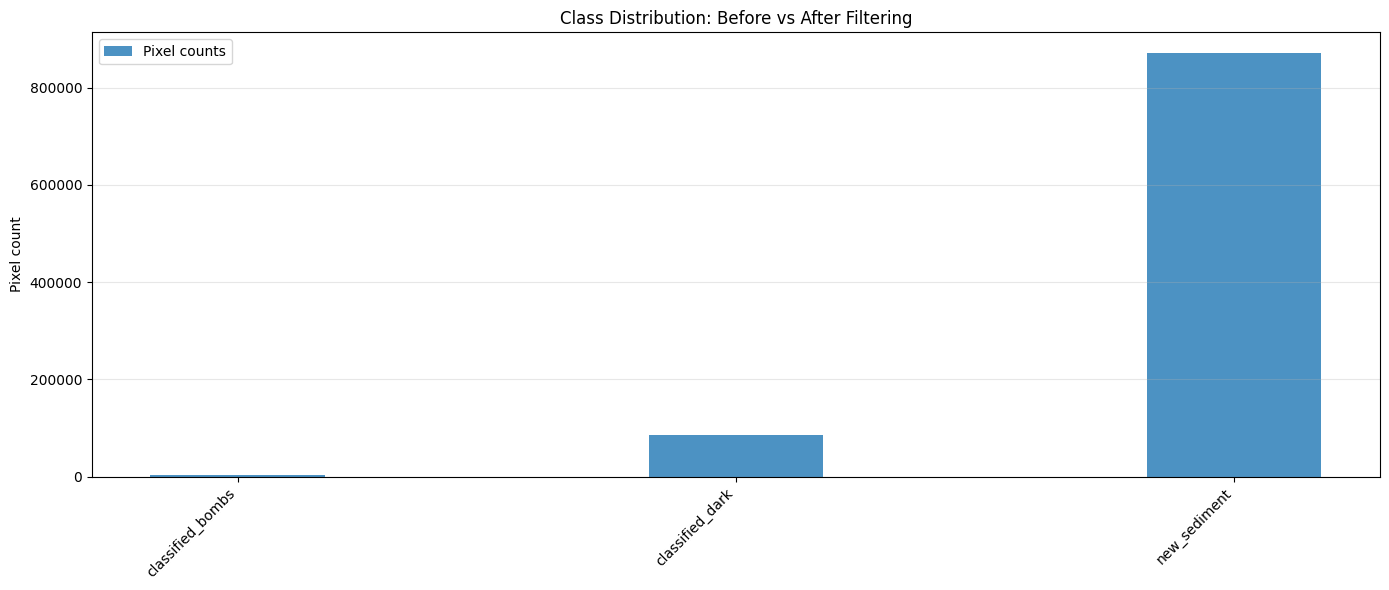

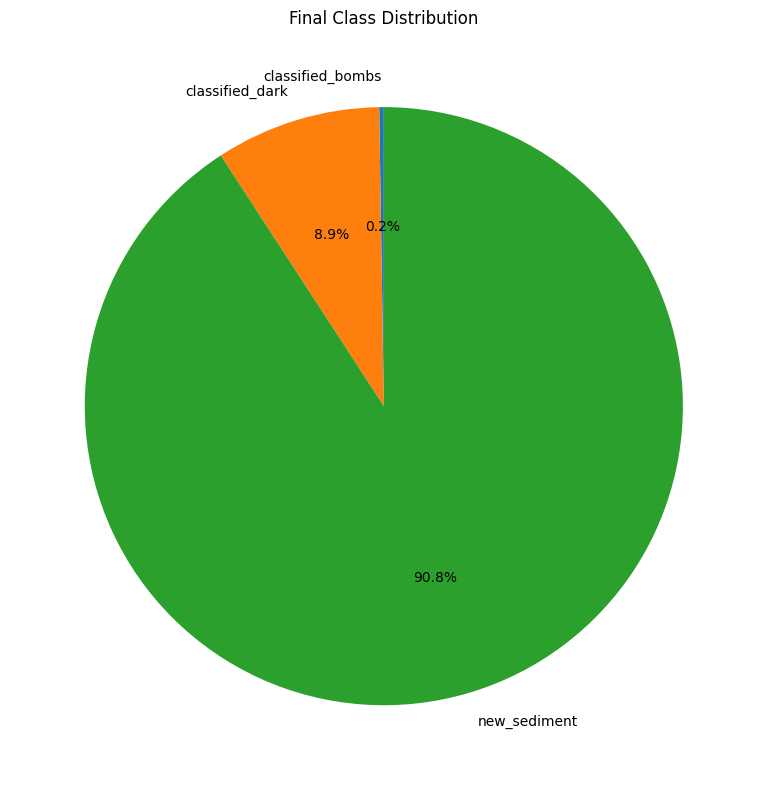

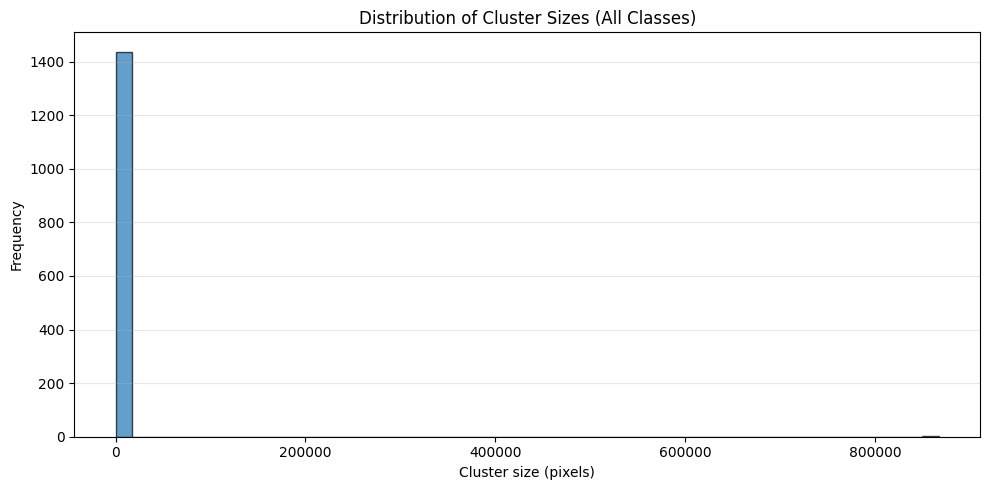


✅ Analysis complete. Returned metrics dictionary.

📝 NARRATIVE SUMMARY
This is the baseline 057 model applied to its own training transect.
Total pixels classified: 958,320

Final distribution (after filtering and merging):
  • classified_bombs: 2,369 pixels (0.25%)
  • classified_dark: 85,599 pixels (8.93%)
  • new_sediment: 870,352 pixels (90.82%)

💡 Merging logic applied:
   • classified_sediment + filtered_bombs + filtered_dark → new_sediment
   • classified_bombs and classified_dark remain unchanged

📊 Merged into new_sediment: 870,352 pixels from:
   • classified_sediment: 867,254 (99.6%)
   • filtered_bombs: 241 (0.0%)
   • filtered_dark: 2,857 (0.3%)


In [ ]:
# # Import the comprehensive analysis function
# from utils.uhi.classification_analysis import analyze_classification_results

# # Analyze the FINAL merged results from this notebook
# # Pipeline: classify_segment → filter_classification → merge_filtered_to_sediment
# # Final classes: classified_bombs, classified_dark, new_sediment

# if "merge_results" not in globals():
#     print("❌ ERROR: merge_results not found!")
#     print("   Please run all pipeline cells (classify → filter → merge) first.")
# else:
#     print("=" * 80)
#     print("📊 CLASSIFICATION ANALYSIS: 057 TRANSECT (3-CLASS MODEL)")
#     print("=" * 80)
#     print(f"Model: SVM trained on transect 057")
#     print(f"Final classes: {merge_results['class_names']}")
#     print(f"Application: Same transect (057)")
#     print(
#         f"\n🔄 Pipeline: classify_segment → filter_classification → merge_filtered_to_sediment"
#     )
#     print("=" * 80)

#     # Analyze FINAL results only (after all pipeline steps)
#     # This shows the final distribution after filtering + merging
#     metrics_057 = analyze_classification_results(
#         classification_map=merge_results["validation_map"],  # FINAL merged map
#         filtered_map=None,  # No comparison needed
#         class_names=merge_results["class_names"],  # FINAL 3 classes
#         track_start=(
#             config.UHI_TRACK_RANGE[0] if hasattr(config, "UHI_TRACK_RANGE") else 0
#         ),
#         figsize=(14, 6),
#         show_plots=True,
#         save_csv="./saved_data/classification_summary_057_on_057.csv",
#     )

#     print("\n" + "=" * 80)
#     print("📝 NARRATIVE SUMMARY")
#     print("=" * 80)
#     print(f"This is the baseline 057 model applied to its own training transect.")
#     print(f"Total pixels classified: {metrics_057['total_pixels']:,}")
#     print(f"\nFinal distribution (after filtering and merging):")

#     for cn in merge_results["class_names"]:
#         count = metrics_057["counts_before"].get(cn, 0)
#         pct = 100.0 * count / metrics_057["total_pixels"]
#         print(f"  • {cn}: {count:,} pixels ({pct:.2f}%)")

#     print(f"\n💡 Merging logic applied:")
#     print(f"   • classified_sediment + filtered_bombs + filtered_dark → new_sediment")
#     print(f"   • classified_bombs and classified_dark remain unchanged")

#     # Show merge summary from merge_results
#     if "merge_summary" in merge_results:
#         total_merged = sum(merge_results["merge_summary"].values())
#         print(f"\n📊 Merged into new_sediment: {total_merged:,} pixels from:")
#         for class_name, count in merge_results["merge_summary"].items():
#             pct = 100.0 * count / total_merged
#             print(f"   • {class_name}: {count:,} ({pct:.1f}%)")

#     print("=" * 80)

---

## 💾 EXPORT COVERAGE STATISTICS

Save classification coverage percentages to CSV for cross-notebook comparison.


In [32]:
# Export coverage statistics for notebook 6 (057 baseline)
import pandas as pd
import os

# Create coverage_stats directory if it doesn't exist
os.makedirs("./coverage_stats", exist_ok=True)

if "merge_results" in globals() and merge_results:
    # Calculate coverage percentages from final merged results
    total_pixels = merge_results["validation_map"].size

    coverage_data = []
    for class_name in merge_results["class_names"]:
        count = np.sum(merge_results["validation_map"] == class_name)
        percentage = 100.0 * count / total_pixels
        coverage_data.append(
            {
                "notebook": "6_svm_057_general",
                "model": "057_on_057",
                "region": "full_transect",
                "class": class_name,
                "pixels": count,
                "percentage": percentage,
            }
        )

    # Save to CSV
    df_coverage = pd.DataFrame(coverage_data)
    output_file = "./coverage_stats/057_on_057_coverage.csv"
    df_coverage.to_csv(output_file, index=False)

    print("✅ Coverage statistics exported!")
    print(f"   File: {output_file}")
    print(f"\n📊 Coverage Summary:")
    print(df_coverage[["region", "class", "percentage"]].to_string(index=False))
else:
    print("❌ ERROR: merge_results not found!")
    print("   Run the pipeline cells first (classify → filter → merge).")

✅ Coverage statistics exported!
   File: ./coverage_stats/057_on_057_coverage.csv

📊 Coverage Summary:
       region            class  percentage
full_transect classified_bombs    0.247203
full_transect  classified_dark    8.932194
full_transect     new_sediment   90.820603
